# Project 03: Gibbs Sampling (Random Algorithm)

In [35]:
import random
import numpy as np
import bamnostic as bs
import seqlogo

#import function for building sequence motif & idenfitying seqs matching to motif
from data_readers import *
from seq_ops import get_seq, reverse_complement
from motif_ops import *

---
## Implement Gibbs Sampler


Gibbs sampling is a MCMC approach to identify enrichments. Here we will implement a method to identify motifs from a set of regions. 

Important considerations:
- We will need to score each sequence with a PWM using the `score_kmer()` or `score_sequence()` functions
    - You will need to investigate into the help documenation and libraries to identify how best to use these functions. 
- These sites are often not strand-specific and so both scores on the negative as well as positive strand should be considered
- To select a random sequence, use `random.randint()` or `numpy.random.randint()`
- To select a new position $m$ (as defined below) use `random.choices()` or `numpy.random.choice()`  

Assumptions: 
- We know $k$ as the length of expected motif
- Each sequence contains the motif



```
GibbsMotifFinder(DNA, k-length)
    random pick of k-length sequences from each line of DNA as Motifs
    for j ← 1 to 10000 or Motifs stops changing
        i ← Random(N) where N is number of DNA entries
        PWM ← PWM constructed from all Motifs except for Motifi
        Motifi ← select position m from PWM-scored k-mers in DNAi in probabilistic fashion from score distribution
    return PFM
```

Probability of chosing position $m = \frac{A_{m}}{\sum_{l}A_{l}}$ for positions $l$ in DNAi


**Note:** I have also added a function to `motif_ops.py` that will calculate the information content of your motifs. This is useful to observe the progression of your Gibbs sampler as well as a measure of convergence. You can use this function as `IC = pfm_ic(pfm)`. You should expect a slow increase of IC until it plateaus such as in the plot below from your lecture slides:

<center><img src='figures/Gibbs_Sampling.png'/ width=600px></center>

---
# Project Start

In [36]:
def GibbsMotifFinder (seqs, k, seed=None):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler
    
    Args: 
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # Use rng to make random samples/selections/numbers
    # Example: randint = rng.integer(1, 10)
    random.seed(seed)
    rng = np.random.default_rng(seed)

    # Pick random k-mer from each seq as starting motif
    motifs = []
    for s in seqs:
        start = rng.integers(0, len(s) - k + 1)
        motifs.append(s[start:start+k])

    ic_trace = []
    window = len(seqs)

    for j in range(10000):
        i = rng.integers(0, len(seqs))

        others = motifs[:i] + motifs[i+1:]
        holdout_pwm = build_pwm(build_pfm(others, k))

        s = seqs[i]
        candidates = []
        scores = []
        for start in range(len(s) - k + 1):
            kmer = s[start:start + k]
            for cand in (kmer, reverse_complement(kmer)):
                candidates.append(cand)
                scores.append(score_kmer(cand, holdout_pwm))

        weights = 2 ** np.array(scores)
        chances = weights / weights.sum()

        motifs[i] = str(rng.choice(candidates, p=chances))

        ic_trace.append(pfm_ic(build_pfm(motifs, k)))
        if j % 1000 == 0:
            print(j, round(ic_trace[-1], 2))

        if j >= window and ic_trace[-1] - ic_trace[-1 - window] < 0.1:
            print("Converged at round", j, "with IC", round(ic_trace[-1], 2))
            break

    GibbsMotifFinder.ic_trace = ic_trace
    return build_pfm(motifs, k)

In [37]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
seq_file="data/GCF_000009045.1_ASM904v1_genomic.fna"
gff_file="data/GCF_000009045.1_ASM904v1_genomic.gff"

seqs = []

for name, seq in get_fasta(seq_file): # For each entry in our FASTA file
    for gff_entry in get_gff(gff_file): # For each entry in our GFF file
        if gff_entry.type == 'CDS': # If this is a coding sequence
            promoter_seq = get_seq(seq, gff_entry.start, gff_entry.end, gff_entry.strand, 50) # Extract 50 bp as a promoter
    
            """
            Because the gibbs sampling assumption is broken in just using promoters,
            and because it takes very long time to randomly progress through so many
            regions, for this example we will pre-filter for sequences that all contain
            part of the shine-dalgarno motif:
            """
            if "AGGAGG" in promoter_seq:
                seqs.append(promoter_seq)

# print(len(seqs))
# print(seqs[0])
# print(seqs[1])

# for s in seqs[:10]:
#     print(len(s), s.find("AGGAGG"))


In [38]:
   pfm = GibbsMotifFinder(seqs, 10, seed=42)
   print(pfm.shape)
   print(round(pfm_ic(pfm), 2))

0 0.8
1000 2.21
2000 3.5
3000 4.94
4000 6.66
5000 9.35
6000 11.38
7000 12.14
8000 12.53
Converged at round 8561 with IC 12.56
(4, 10)
12.56


---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

0 0.79
1000 2.27
2000 3.79
3000 5.32
4000 7.49
5000 9.89
6000 11.34
7000 12.27
8000 12.46
9000 12.61
Converged at round 9079 with IC 12.61


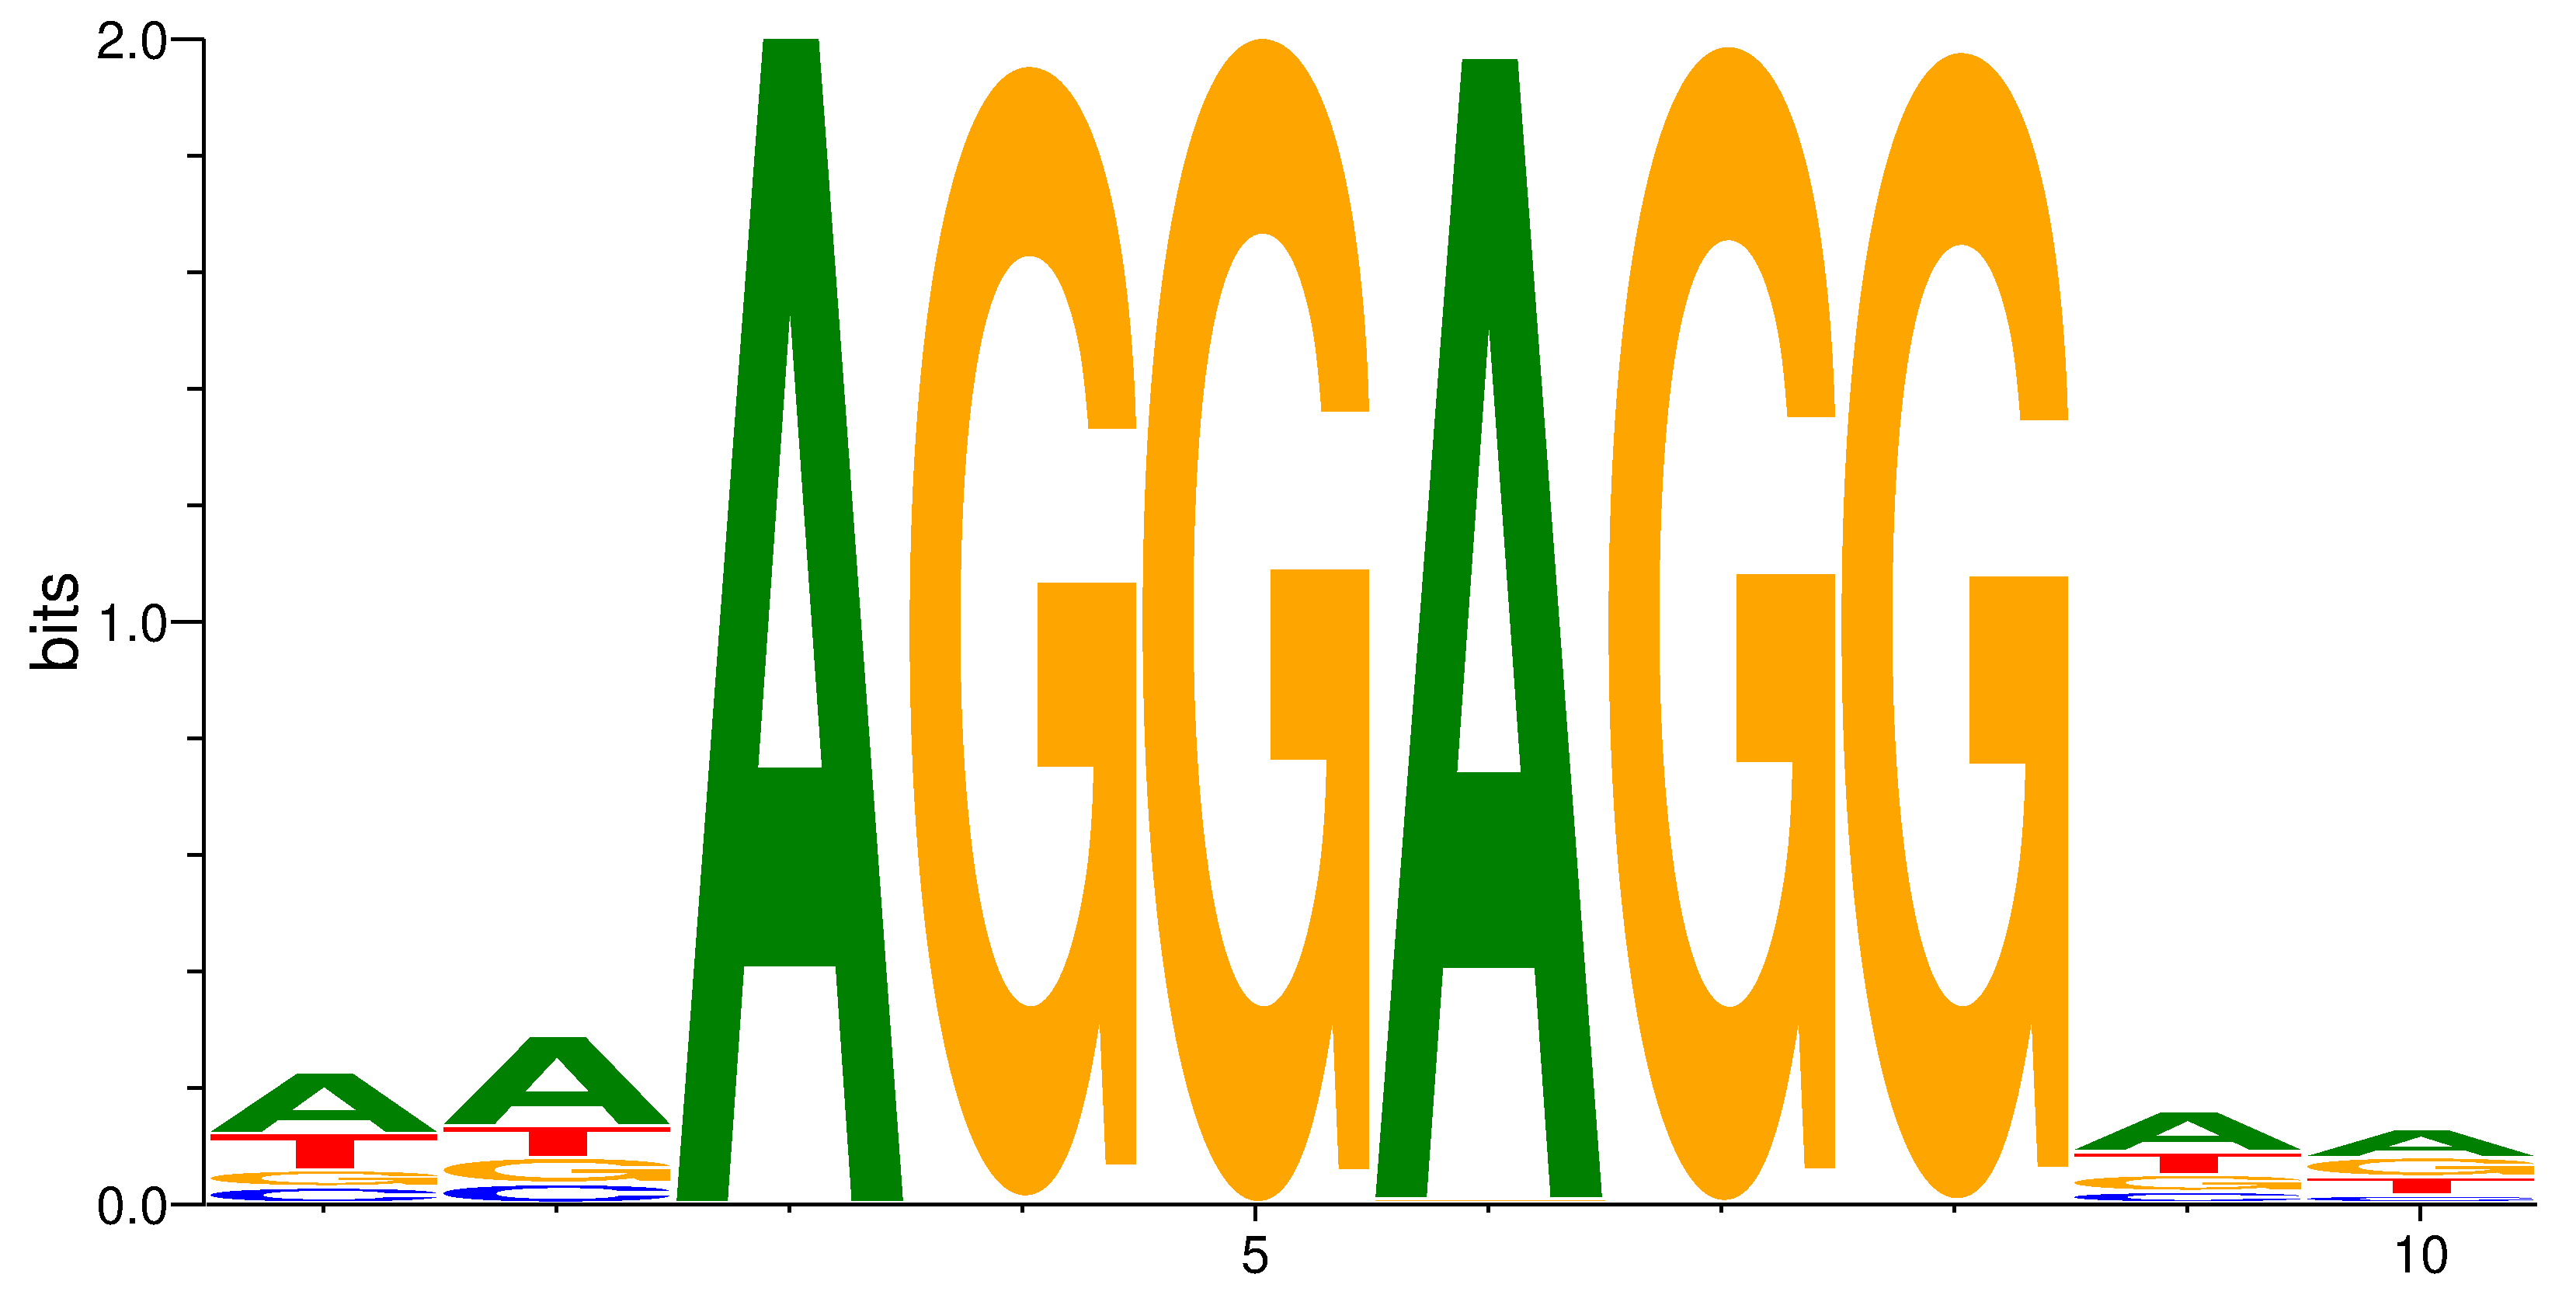

In [39]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_pfm.T))

---
# Challenge Yourself
Now that you potentially have a working skeleton of the project, try to work with the new NRF1 ChIP-seq data: `data/nrf1_gibbs.fa`.

Upon inspection, you will see that it is just a FASTA file. Since it is a FASTA file, you already have an example in the code above on how to access FASTA files. It is up to you to do the correct data ingest with it, though.

---
# NRF1 Driver Program
Modify the code below and test your Gibbs Sampler.

0 0.12
1000 0.34
2000 0.48
3000 0.67
4000 0.9
5000 1.09
6000 1.34
7000 1.73
8000 2.04
9000 2.36


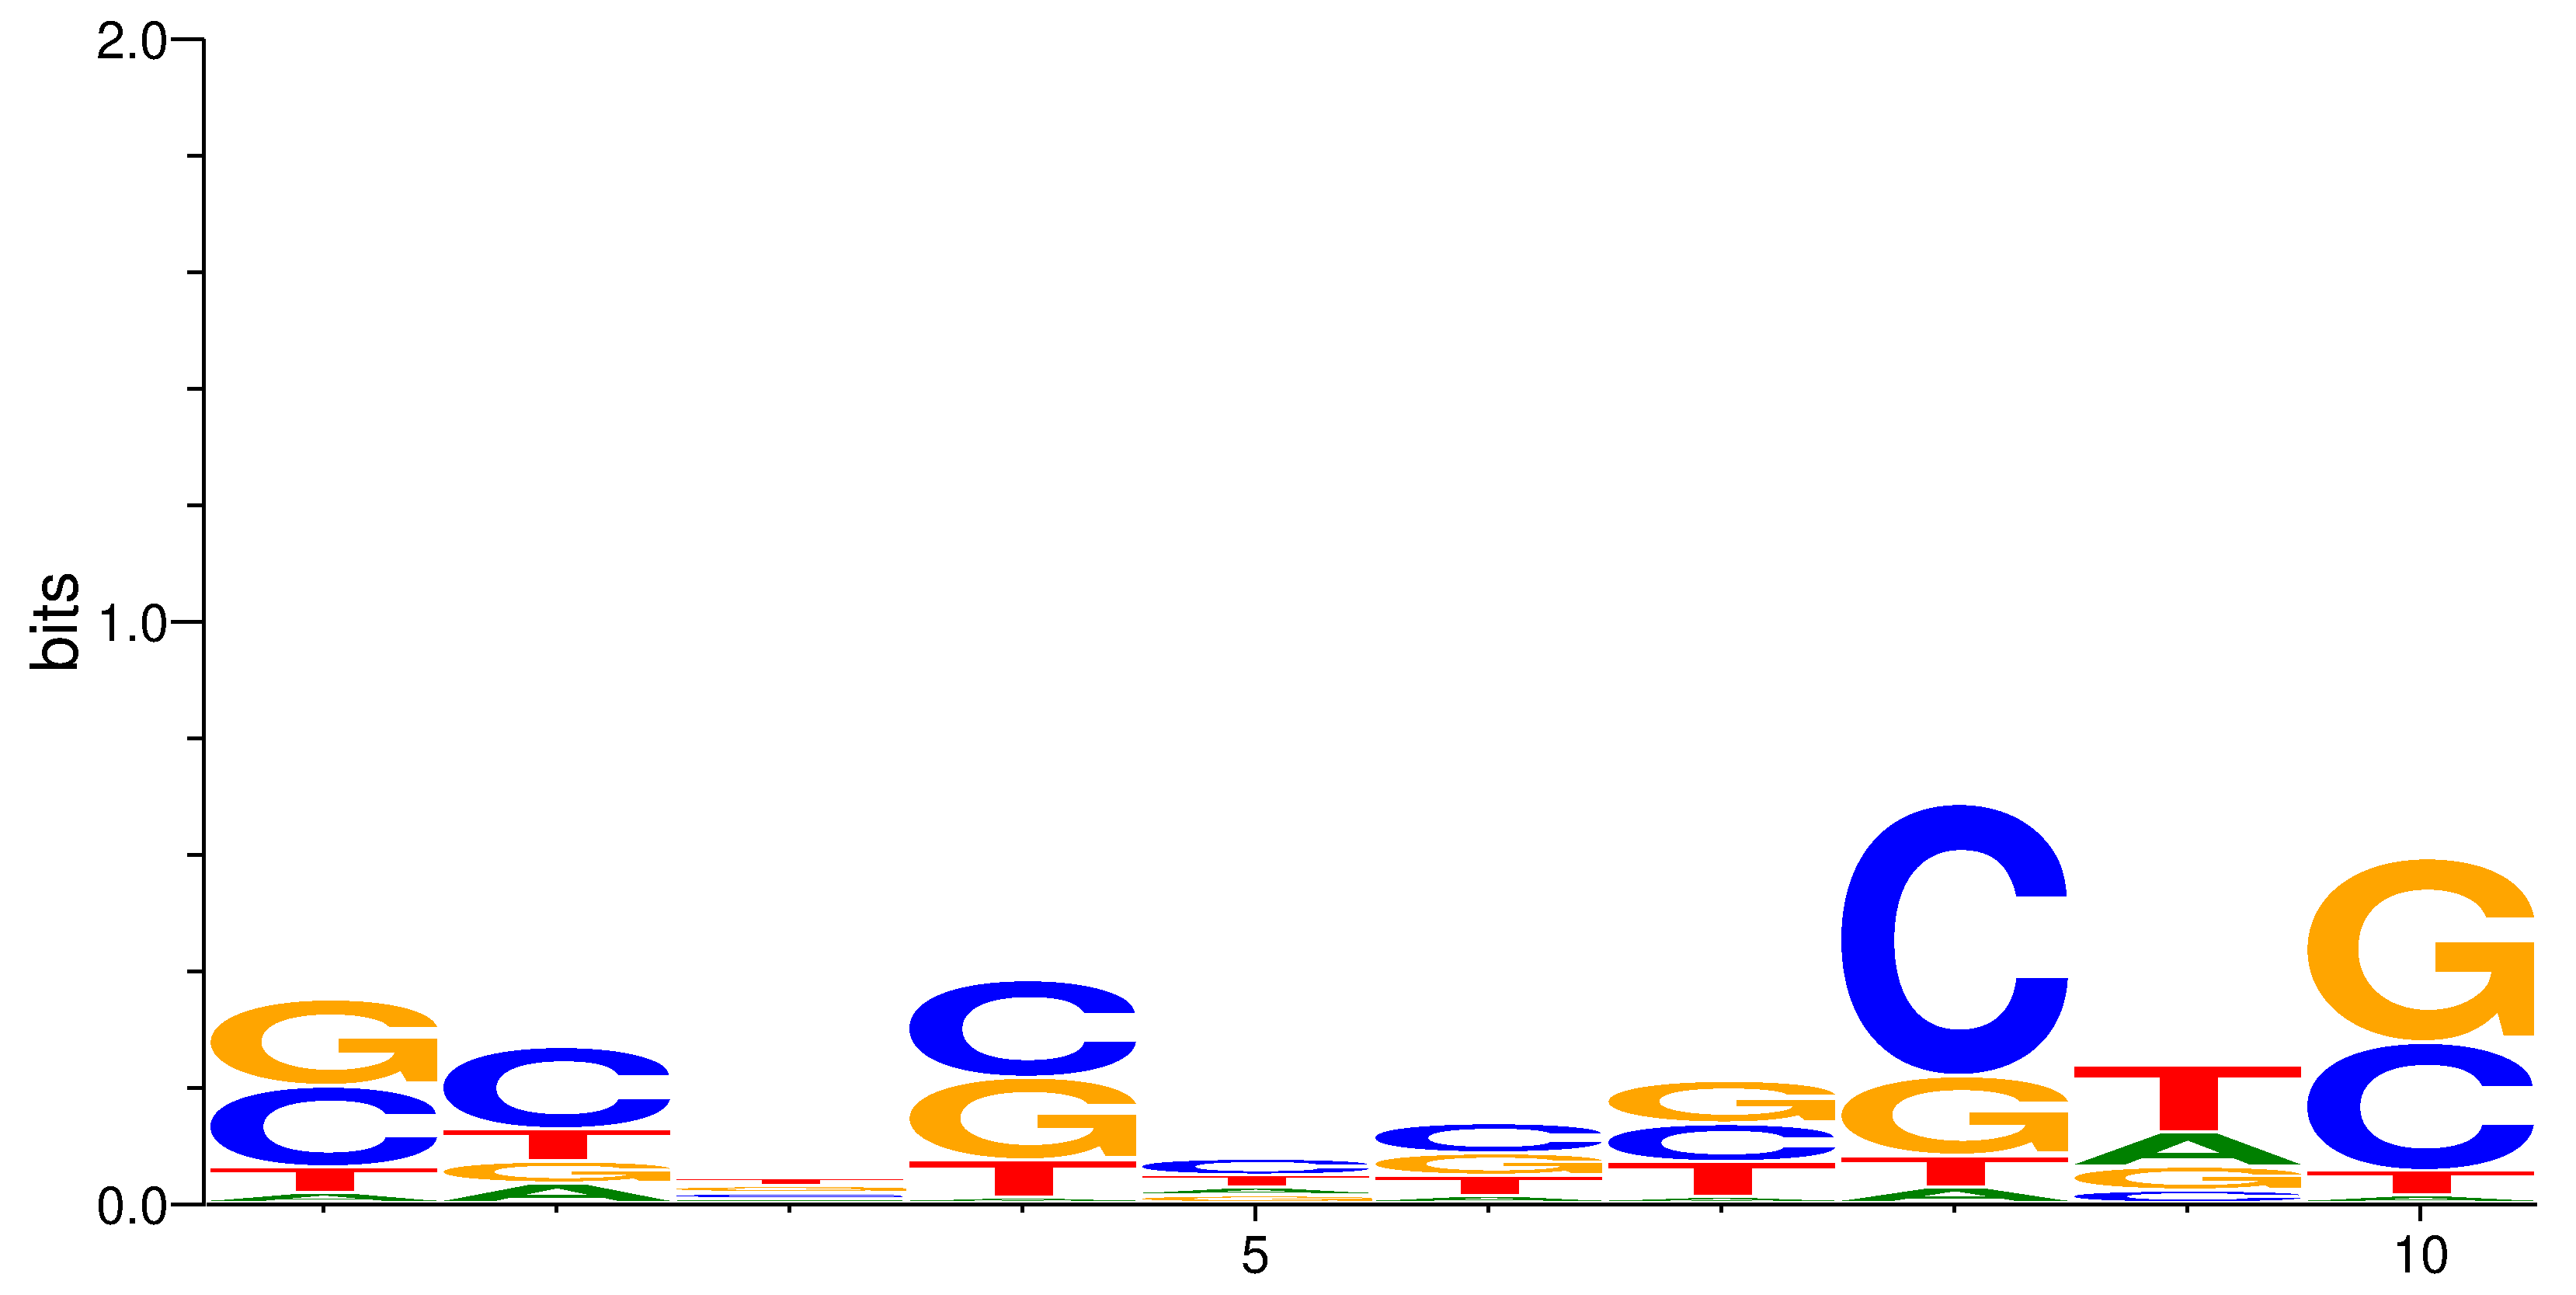

In [40]:
# Here we test your Gibbs sampler.
# You do not need to edit this or the section below. This is the Driver program

#read promoters, store in a list of strings
nrf1_file="data/nrf1_gibbs.fa"

nrf1_peaks = []

for name, seq in get_fasta(nrf1_file):
    nrf1_peaks.append(seq.upper())

# Random sample of 1000 peaks so sampler runs in reasonable time
random.seed(1)
nrf1_peaks = random.sample(nrf1_peaks, 1000)

# Run the gibbs sampler:
nrf1_pfm = GibbsMotifFinder(nrf1_peaks, 10)

# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = nrf1_pfm.T))

In [41]:
# temporaryy: scanning through the sequence
print(len(nrf1_peaks))

lengths = [len(s) for s in nrf1_peaks]
print(min(lengths), max(lengths))

print(nrf1_peaks[0][:100])

print(sum("N" in s for s in nrf1_peaks))

1000
75 75
CCTGCAAAACCTGGAAGGGTAGGGGAAGTCAGGGCAGGGAAGCAGGGAGCTGAGTCACGGGACAAAGGGAGAGGA
0


In [42]:
# temporary, to check how many motifs are in seq
print(sum("CGCATGCG" in s for s in nrf1_peaks), "of", len(nrf1_peaks))

11 of 1000
